We will be building a basic chatbot , which uses a state to store the conversation , but at the same time it will be capable to handle the large conversation by summarizing the previous messages in short.

In [153]:
#imports
import os
import sys
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END,MessagesState,add_messages
from langchain_core.messages import HumanMessage,SystemMessage,RemoveMessage,BaseMessage,AIMessage
from langchain_core.prompts import SystemMessagePromptTemplate
from typing import List,Annotated,TypedDict,Literal

In [154]:
#import env
load_dotenv()

GROQ_LLM_API_KEY = os.getenv("GROQ_LLM_API_KEY")
GEMINI_LLM_API_KEY= os.getenv("GEMINI_LLM_API_KEY")

In [155]:
#setting Up logger

path = os.path.abspath("..")
if path not in sys.path:
    sys.path.insert(0,path)

from RSYLogger.Logger import Logger
logger = Logger("9 Handling Large States with Summary")

In [156]:
#LLM
try:
    logger.info("Initializing LLM : GROQ")
    llm = ChatGroq(model="llama-3.3-70b-versatile",temperature=0.7,api_key=GROQ_LLM_API_KEY)
    logger.info("LLM Initialization: Completed")
except Exception as e:
    logger.info("LLM Initialization: Failed")
    print(e)
    logger.info(e)
    
logger.info(f"{'-'*30}\n")

In [157]:
class GraphState(TypedDict):
    messages:Annotated[List[BaseMessage],add_messages]
    summary:str

In [158]:
templateMsg = """
You are a State Manager Summarizer Agent. 

Your goal is to distill the conversation history into a high-density, concise summary.
Follow these rules:
1. Identify the core intent of the user.
2. Preserve key facts, technical values, and specific user preferences.
3. List any unresolved questions or pending tasks.
4. Keep the summary as short as possible using clear and professional language without losing any context.

Previous Summary:
{summary} 
New Messages:
{messages}

Provide only the summary text.
"""
summarizeTemplate = SystemMessagePromptTemplate.from_template(template=templateMsg)

In [159]:
def summarizeState(state:GraphState):
    messages = state.get("messages",[])
    newState={}
    if len(messages) > 2:
        print("Summarizing state")
        messages_to_remove =[RemoveMessage(id=message.id) for message in messages[:-1]]
        last_message = messages[-1]
        system_message = summarizeTemplate.format(messages=messages[:-1],summary=state.get('summary',''))
        # system_message.pretty_print()
        response = llm.invoke([system_message])
        newState=  {
            "messages":messages_to_remove,
            'summary':response.content
        }
        print("\nNewState")
        print(f"Summary :{response.content}")
        print(f"messages :{newState.get("messages")}\n")
        return newState
    print("State in under limit to need to fetch summary")
    return state
        

In [160]:
test_messages = [
    # Level 1-2: Identity & Age
    AIMessage(content="Sh. Narendra Modi is the Prime Minister of India.", id="m1"),
    HumanMessage(content="What is his age?", id="m2"),
    
    # Level 3-4: Stats & Birthplacea
    AIMessage(content="He is currently 75 years old.", id="m3"),
    HumanMessage(content="Where was he born?", id="m4"),
    
    # Level 5-6: Geography & Career
    AIMessage(content="He was born in Vadnagar, Gujarat.", id="m5"),
    HumanMessage(content="What was his job before politics?", id="m6"),
    
    # Level 7-8: Background & Tenure
    AIMessage(content="He was an RSS pracharak and previously helped at a tea stall.", id="m7"),
    HumanMessage(content="How long was he Chief Minister of Gujarat?", id="m8"),
    
    # Level 9-10: Records & Recent Status
    AIMessage(content="He served as Gujarat's CM for 13 years (2001-2014).", id="m9"),
    HumanMessage(content="When did he start his first term as PM?", id="m10")
]

# Test your function:
# summarizeState({'messages': test_messages, 'summary': ""})

newState=summarizeState({
    'messages':test_messages,
    'summary':''
})

print(newState)

Summarizing state

NewState
Summary :The user inquired about Indian Prime Minister Narendra Modi. Key facts include: he is 75 years old, born in Vadnagar, Gujarat, and previously worked as an RSS pracharak and at a tea stall. He served as Gujarat's Chief Minister for 13 years (2001-2014). There are no unresolved questions or pending tasks.
messages :[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='m1'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='m2'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='m3'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='m4'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='m5'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='m6'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='m7'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='m8'), RemoveM

In [161]:
fetchInfo_Msg = """
### Role
You are a context-aware assistant. You answer the user's latest question using the provided conversation summary as your memory.

### Context (History)
{summary}

### Instructions
1.  **Contextual Linking**: Use the summary to resolve pronouns (e.g., if summary says "Modi" and user asks "his age", "his" refers to Modi).
2.  **Brevity**: Provide a direct, factual answer based on the summary and your internal knowledge.
3.  **Gap Handling**: If the summary doesn't contain enough info to answer a specific follow-up, use your general knowledge but stay consistent with the summary's facts.
4.  **No Meta-Talk**: Do not mention "The summary states" or "According to the history." Just answer the question.
5.  If summary is not present , it means user doen't have any previous conversation 
6.  If no summary is present , you have to response to the query passed by the user in its message
### Output
[Direct Answer]
"""

fetchInfo_Template = SystemMessagePromptTemplate.from_template(template=fetchInfo_Msg)
def fetchInformation(state:GraphState):
    summary = state.get("summary","")
    messages = state.get("messages",[])

    system_msg = fetchInfo_Template.format(summary=summary)
    # system_msg.pretty_print()
    print(f"Summary passed in context {summary}")
    print(f"\nMessages passed in context {len(messages)}\n")
    # for i in messages:
    #     i.pretty_print()
    response = llm.invoke([system_msg]+messages)
    response.pretty_print()
    return {
        "messages":[response],
        "summary":summary
    }



In [162]:
def askQuery(state:GraphState):
    print(f"{'-'*20}")
    print("How can i help you ?")
    query = input()
    prompt = HumanMessage(content=query)
    prompt.pretty_print()
    return {
        "messages":add_messages(state.get("messages",[]),prompt),
        "summary":state.get("summary","")
    }


In [163]:
def wantToContinue(state:GraphState)-> Literal["askQuery","__end__"]:
    print("Do you want to continue Yes/No")
    decision = input("Do you want to continue ? yes or no: ").lower().strip()
    if decision == "no":
        print("User Selected : NO")
        return "__end__"
    else:
        print("User Selected : Yes")
        return "askQuery"

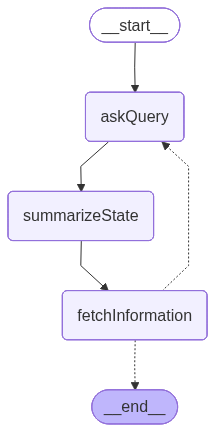

In [164]:
workflow = StateGraph(GraphState)

workflow.add_node("askQuery",askQuery)
workflow.add_node("summarizeState",summarizeState)
workflow.add_node("fetchInformation",fetchInformation)

workflow.set_entry_point("askQuery")
workflow.add_edge("askQuery","summarizeState")
workflow.add_edge("summarizeState","fetchInformation")
workflow.add_conditional_edges("fetchInformation",wantToContinue,{
    "askQuery":"askQuery",
    "__end__":END
})

app = workflow.compile()
app


In [165]:
def ChatBot():
    app.invoke({
        "messages":[],
        "summary":""
    })

In [166]:
ChatBot()

--------------------
How can i help you ?
================================ Human Message =================================

Who is the Prime Minister of India ?
State in under limit to need to fetch summary
Summary passed in context 

Messages passed in context 1

================================== Ai Message ==================================

Dhirendra Sharma is not the Prime Minister of India. The current Prime Minister of India is Narendra Modi.
Do you want to continue Yes/No
User Selected : Yes
--------------------
How can i help you ?
================================ Human Message =================================

from which state modi belong ?
Summarizing state

NewState
Summary :The user inquired about the Prime Minister of India. The current Prime Minister is Narendra Modi. There are no unresolved questions or pending tasks.
messages :[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='caa50589-e2ab-4b25-80b5-4ea664f75eb4'), RemoveMessage(content='', ad